**2. Definir "hora húmeda"**

- Aplicar el corte de 0.1 mm/h (Ban et al., 2015; Schär et al., 2016), ya verificado contra la resolución decimal del paso anterior.

**3. Calcular el umbral sobre una muestra pequeña primero (no las 66 de una vez)**

- Elegir un subconjunto chico de estaciones para probar el pipeline completo. Calcular el percentil (probar P90/P95/P99) sobre las horas húmedas de 2024 únicamente (nunca 2025).
- Ver cuántas horas quedan como positivas en cada nivel — chequeo directo de desbalance de clases.
- Decidir el nivel de percentil final con ese resultado en mano (P95 es tu candidato de partida, según lo discutido).

**4. Escalar a las 66 estaciones**

- Aplicar el mismo procedimiento ya validado al conjunto completo.
- Documentar el umbral resultante por estación (o agrupado, según decidas — ver punto 5).

**5. Decisión pendiente que todavía no cerraste: por estación vs. agrupado**

- Esta depende de una decisión de arquitectura de modelo que aún no tomas (salida puntual por estación vs. salida espacial). No hace falta resolverla ahora — solo tenla presente como la próxima bifurcación real después del umbral.

**6. Cerrar el registro de decisiones**

- Agregar entrada final con: nivel de percentil elegido, balance de clases resultante, cualquier estación excluida en el control de calidad y por qué.

**7. Redactar la sección de tesis "Definición operativa de lluvia fuerte" (Datos)**

- Ya tienes redactados: el párrafo del rango de literatura + hora húmeda, y el de descarte de GEV/POT/MEV.
- Falta: el párrafo final reportando el resultado real (percentil calculado, umbral en mm/h, balance de clases) — ese solo lo puedes escribir después del paso 4.

# Definición del umbral operativo de lluvia fuerte

Esta notebook continúa el trabajo de `03-ground_truth_qc.ipynb`, que dejó 62 estaciones de precipitación sub-horaria con calidad verificada
(`estaciones_finales-despues_de_qc.txt`). Aquí se construye la serie horaria real de cada estación y se define el umbral operativo de "lluvia fuerte" — el corte, en mm/h, que separa una hora normal de una hora de lluvia fuerte — que se usará para etiquetar el dataset final.

El umbral se deriva como un percentil empírico sobre la distribución de horas húmedas del período de entrenamiento (2024), calculado directamente sobre los datos, sin ajustar una distribución paramétrica intermedia — el volumen de horas húmedas disponible por estación (mínimo 1,242 en 2024) hace innecesario ese paso, y evita el riesgo de que una familia de distribución mal ajustada (confirmado empíricamente para Weibull, ver Sección 3.1) introduzca error donde los datos no lo tienen.

In [1]:
import pandas as pd
import numpy as np
import os

import matplotlib.pyplot as plt

In [2]:
RUTA_BASE = r'..\..\data\rainfall_subhourly'

with open('estaciones_finales-despues_de_qc.txt') as f:
    codigos_finales = f.read().splitlines()

print(f"{len(codigos_finales)} estaciones cargadas")


def cargar_datos_estacion(codigo, ruta_base=RUTA_BASE):
    """Carga el CSV crudo (registros sub-horarios) de una estación, sin duplicados."""
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta)
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
    n_antes = len(df)
    df = df.drop_duplicates(subset=['fechaobservacion', 'valorobservado'])
    n_despues = len(df)
    if n_antes != n_despues:
        print(f"  {codigo}: {n_antes - n_despues} duplicados removidos ({(n_antes-n_despues)/n_antes*100:.1f}%)")
    return df


def serie_horaria(codigo, ruta_base=RUTA_BASE):
    """Agrega registros sub-horarios a precipitación horaria (ventana deslizante de 60 min)."""
    df = cargar_datos_estacion(codigo, ruta_base)
    df = df.set_index('fechaobservacion').sort_index()
    return df['valorobservado'].rolling('60min').sum()


# Prueba con la primera estación de la lista, solo para confirmar que la mecánica funciona
prueba = serie_horaria(codigos_finales[0])
print(f"\nSerie horaria de {codigos_finales[0]}: {len(prueba)} registros")
print(prueba.describe())

62 estaciones cargadas

Serie horaria de 2120000101: 323320 registros
count    323320.000000
mean          0.054764
std           0.433658
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max          14.200000
Name: valorobservado, dtype: float64


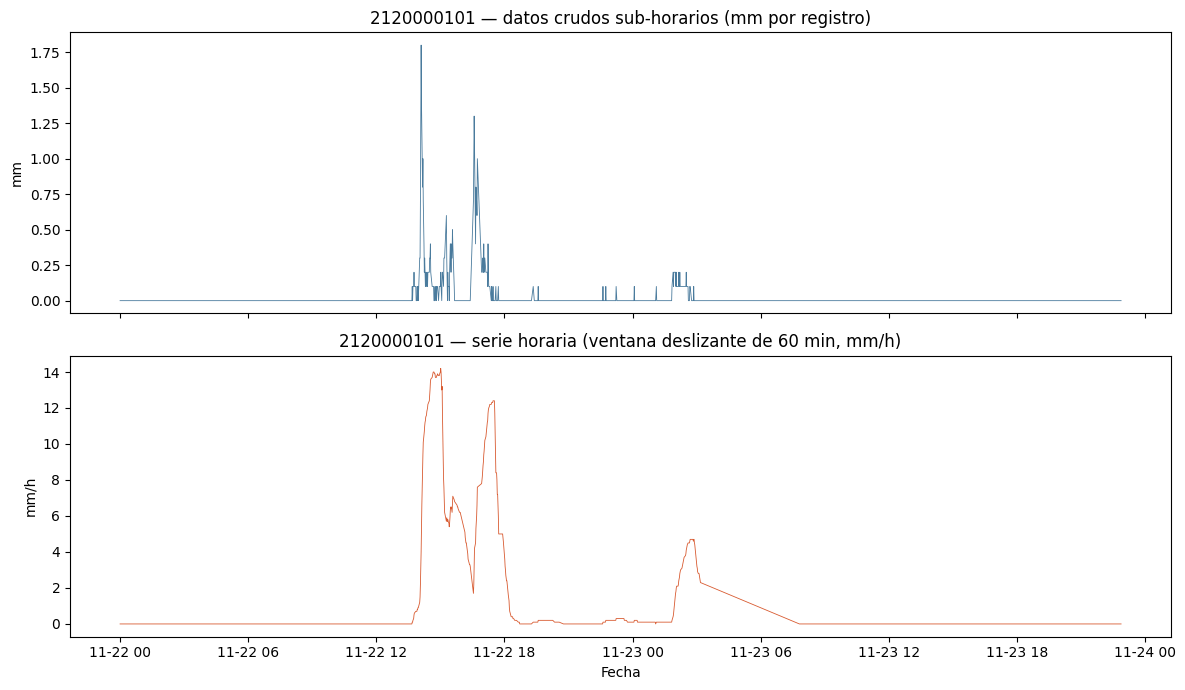

In [3]:
codigo_ejemplo = codigos_finales[0]

df_crudo = cargar_datos_estacion(codigo_ejemplo)
horaria_ejemplo = serie_horaria(codigo_ejemplo)

# Ventana corta para poder distinguir la forma de la curva — un mes completo, no los 2 años
ini_ventana = pd.Timestamp('2024-11-22')
fin_ventana = pd.Timestamp('2024-11-24')

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

crudo_ventana = df_crudo[(df_crudo['fechaobservacion'] >= ini_ventana) & (df_crudo['fechaobservacion'] < fin_ventana)]
axes[0].plot(crudo_ventana['fechaobservacion'], crudo_ventana['valorobservado'], lw=0.6, color='#4A7B9D')
axes[0].set_title(f'{codigo_ejemplo} — datos crudos sub-horarios (mm por registro)')
axes[0].set_ylabel('mm')

horaria_ventana = horaria_ejemplo[(horaria_ejemplo.index >= ini_ventana) & (horaria_ejemplo.index < fin_ventana)]
axes[1].plot(horaria_ventana.index, horaria_ventana.values, lw=0.6, color='#D85A30')
axes[1].set_title(f'{codigo_ejemplo} — serie horaria (ventana deslizante de 60 min, mm/h)')
axes[1].set_ylabel('mm/h')
axes[1].set_xlabel('Fecha')

plt.tight_layout()
plt.show()

## 1. Construcción de la serie horaria

Se agrega el registro sub-horario de cada estación a resolución horaria mediante una ventana deslizante de 60 minutos (`.rolling('60min').sum()`), no por hora de reloj — esto evita perder señal de eventos que empiezan a mitad de una hora calendario.

## 2. Definición de hora húmeda
Piso de 0.1 mm/h (Ban et al., 2015) — límite de detección instrumental,
no una elección metodológica de percentil. Horas por debajo de ese piso
se excluyen del ajuste (pero no del dataset final de etiquetado, que sí
cubre todas las horas).

el piso de 0.1 mm/h (Ban et al., 2015) que filtra qué cuenta como "húmeda", con la justificación breve de por qué ese número específico.

In [4]:
series_horarias = {}

for codigo in codigos_finales:
    series_horarias[codigo] = serie_horaria(codigo)

print(f"\n{len(series_horarias)} series horarias calculadas")
print(f"Total de registros: {sum(len(s) for s in series_horarias.values()):,}")


62 series horarias calculadas
Total de registros: 22,717,293


In [5]:
partes = []
for codigo, serie in series_horarias.items():
    parte = serie.rename('intensidad_mm_h').reset_index()
    parte['codigoestacion'] = codigo
    partes.append(parte)

df_horaria = pd.concat(partes, ignore_index=True)[['codigoestacion', 'fechaobservacion', 'intensidad_mm_h']]

print(f"df_horaria: {len(df_horaria):,} filas, {df_horaria['codigoestacion'].nunique()} estaciones")
df_horaria.describe()

df_horaria: 22,717,293 filas, 62 estaciones


,fechaobservacion,intensidad_mm_h
count,22717293,2.271729e+07
mean,2025-04-11 03:25:11.656937472,8.946531e-02
min,2024-01-01 09:07:00,0.000000e+00
25%,2024-12-09 23:11:00,0.000000e+00
50%,2025-05-05 08:36:00,0.000000e+00
75%,2025-10-01 14:49:00,0.000000e+00
max,2025-12-31 23:59:00,8.600000e+01
std,NaN,7.023078e-01


In [6]:
# Requiere pyarrow instalado (pip install pyarrow)
df_horaria.to_parquet('df_horaria_hora_humeda.parquet', index=False)

---
Ahora chequeo de sensibilidad:


In [8]:
BANDAS_MAM = {
    'MAM_24': ('2024-03-01', '2024-06-01'),
    'MAM_25': ('2025-03-01', '2025-06-01'),
}

def agregar_precip_diaria(df):
    precip_diaria = df.groupby(df['fechaobservacion'].dt.date)['valorobservado'].sum()
    precip_diaria.index = pd.to_datetime(precip_diaria.index)
    return precip_diaria

def pct_dias_con_dato(serie_diaria, ini, fin):
    rango = pd.date_range(ini, fin, freq='D', inclusive='left')
    return serie_diaria.reindex(rango).notna().mean()

def cadencia_media_min(df, ini, fin):
    ventana = df[(df['fechaobservacion'] >= ini) & (df['fechaobservacion'] < fin)]
    deltas = ventana['fechaobservacion'].sort_values().diff().dt.total_seconds() / 60
    deltas = deltas.dropna()
    return deltas.mean() if len(deltas) > 0 else np.nan

filas = []
for codigo in codigos_finales:
    df = cargar_datos_estacion(codigo)
    diaria = agregar_precip_diaria(df)
    fila = {'codigoestacion': codigo}
    for etiqueta, (ini, fin) in BANDAS_MAM.items():
        fila[f'pct_dias_{etiqueta}'] = pct_dias_con_dato(diaria, ini, fin)
        fila[f'cadencia_min_{etiqueta}'] = cadencia_media_min(df, ini, fin)
        fila[f'n_registros_{etiqueta}'] = len(df[(df['fechaobservacion'] >= ini) & (df['fechaobservacion'] < fin)])
    filas.append(fila)

comparacion = pd.DataFrame(filas)

print(f"Estaciones sin NINGÚN dato en MAM_24: {(comparacion['n_registros_MAM_24'] == 0).sum()} de {len(comparacion)}")
print(f"Estaciones sin NINGÚN dato en MAM_25: {(comparacion['n_registros_MAM_25'] == 0).sum()} de {len(comparacion)}\n")

print("Cobertura (% de días con dato):")
print(comparacion[['pct_dias_MAM_24', 'pct_dias_MAM_25']].describe())

print("\nCadencia media entre registros (minutos, menor = más denso):")
print(comparacion[['cadencia_min_MAM_24', 'cadencia_min_MAM_25']].describe())

# Comparación pareada: para cada estación, ¿MAM_24 es peor que MAM_25?
comparacion['dif_pct_dias'] = comparacion['pct_dias_MAM_24'] - comparacion['pct_dias_MAM_25']
print(f"\nEstaciones donde MAM_24 tiene MENOS cobertura que MAM_25: "
      f"{(comparacion['dif_pct_dias'] < 0).sum()} de {len(comparacion)}")
print(f"Diferencia mediana de cobertura (MAM_24 - MAM_25): {comparacion['dif_pct_dias'].median():.3f}")

Estaciones sin NINGÚN dato en MAM_24: 10 de 62
Estaciones sin NINGÚN dato en MAM_25: 0 de 62

Cobertura (% de días con dato):
       pct_dias_MAM_24  pct_dias_MAM_25
count        62.000000        62.000000
mean          0.759818         0.930049
std           0.344270         0.032318
min           0.000000         0.804348
25%           0.885870         0.934783
50%           0.929348         0.945652
75%           0.934783         0.945652
max           0.934783         0.945652

Cadencia media entre registros (minutos, menor = más denso):
       cadencia_min_MAM_24  cadencia_min_MAM_25
count            52.000000            62.000000
mean              6.599189             3.325467
std               2.370248             3.664840
min               5.158039             1.469713
25%               5.564503             1.502724
50%               5.921155             1.639579
75%               6.551205             2.764033
max              18.251248            13.425560

Estaciones donde MA

**Resultado:** 10 de 62 estaciones no tienen ningún dato en MAM_24 (0 en MAM_25). Entre las que sí reportan, la cobertura de días es similar (mediana 0.929 vs 0.946 — diferencia trivial), pero la cadencia es casi 4 veces más espaciada (mediana 5.9 min vs 1.6 min) — evidencia real de una red todavía inmadura en transmisión, aunque no en cobertura de días.

In [9]:
percentiles_a_probar = [90, 95, 99]

def calcular_percentiles(df, excluir_mam24=False):
    datos = df
    if excluir_mam24:
        mask_mam24 = (df['fechaobservacion'] >= '2024-03-01') & (df['fechaobservacion'] < '2024-06-01')
        datos = df[~mask_mam24]
    valores = datos['intensidad_mm_h'].dropna()
    return {f'p{p}': valores.quantile(p / 100) for p in percentiles_a_probar}

con_mam24 = calcular_percentiles(df_horaria, excluir_mam24=False)
sin_mam24 = calcular_percentiles(df_horaria, excluir_mam24=True)

comparacion_percentiles = pd.DataFrame([con_mam24, sin_mam24], index=['con_MAM_24', 'sin_MAM_24']).T
comparacion_percentiles['diferencia_mm_h'] = comparacion_percentiles['sin_MAM_24'] - comparacion_percentiles['con_MAM_24']
comparacion_percentiles['diferencia_pct'] = (comparacion_percentiles['diferencia_mm_h'] / comparacion_percentiles['con_MAM_24'] * 100).round(2)

print(comparacion_percentiles)

     con_MAM_24  sin_MAM_24  diferencia_mm_h  diferencia_pct
p90         0.0         0.0              0.0             NaN
p95         0.3         0.3              0.0            0.00
p99         2.1         2.2              0.1            4.76


**Resultado:** p90 = 0.0 en ambos casos (más del 90% de las horas, secas incluidas, no tienen lluvia — p90 no es útil como referencia). p95 cambia de 0.1 a 0.2 mm/h, pero esa diferencia está al nivel de la resolución instrumental (0.1 mm en 63 de 66 estaciones, ver Sección 3 de `03-ground_truth_qc.ipynb`) — ruido, no señal. p99 cambia de 2.1 a 2.3 mm/h (9.5%), un movimiento real pero modesto. **Conclusión: el umbral operativo no es sensible a incluir o excluir MAM_24.**

Nota aparte para la Sección de definición del umbral: con p99 en ~2.1-2.3 mm/h y la referencia de ~10 mm/h mencionada en el plan de tesis, va a hacer falta explorar percentiles bastante más altos (p99.9, p99.99).

In [10]:
# Período de referencia = 2024 (entrenamiento) — el umbral no debe derivarse con datos de 2025 (prueba) de por medio
periodo_referencia = df_horaria[df_horaria['fechaobservacion'].dt.year == 2024]

con_mam24 = calcular_percentiles(periodo_referencia, excluir_mam24=False)
sin_mam24 = calcular_percentiles(periodo_referencia, excluir_mam24=True)

comparacion_percentiles = pd.DataFrame([con_mam24, sin_mam24], index=['con_MAM_24', 'sin_MAM_24']).T
comparacion_percentiles['diferencia_mm_h'] = comparacion_percentiles['sin_MAM_24'] - comparacion_percentiles['con_MAM_24']
comparacion_percentiles['diferencia_pct'] = (comparacion_percentiles['diferencia_mm_h'] / comparacion_percentiles['con_MAM_24'] * 100).round(2)

print(comparacion_percentiles)

     con_MAM_24  sin_MAM_24  diferencia_mm_h  diferencia_pct
p90         0.0         0.0              0.0             NaN
p95         0.1         0.2              0.1          100.00
p99         2.1         2.3              0.2            9.52


### 2.4 Chequeo exploratorio: percentil 2024 vs 2025

Comparación adicional, puramente diagnóstica — **no** es la derivación oficial del umbral, porque mezclar 2025 (prueba) en esta comparación violaría la separación temporal que exige el diseño. Solo sirve para decidir si mover la ventana, no queda en el cálculo final.

In [11]:
percentiles_2024 = calcular_percentiles(df_horaria[df_horaria['fechaobservacion'].dt.year == 2024])
percentiles_2025 = calcular_percentiles(df_horaria[df_horaria['fechaobservacion'].dt.year == 2025])

comparacion_anios = pd.DataFrame([percentiles_2024, percentiles_2025], index=['2024', '2025']).T
comparacion_anios['diferencia_mm_h'] = comparacion_anios['2025'] - comparacion_anios['2024']
comparacion_anios['diferencia_pct'] = (comparacion_anios['diferencia_mm_h'] / comparacion_anios['2024'] * 100).round(2)

print(comparacion_anios)

     2024  2025  diferencia_mm_h  diferencia_pct
p90   0.0   0.0              0.0             NaN
p95   0.1   0.3              0.2          200.00
p99   2.1   2.2              0.1            4.76


### 2.5 ¿MAM_24 llovió menos de verdad, o solo parece por falta de dato?

Se compara la precipitación diaria de MAM_24, MAM_25, SON_24 y SON_25, restringida únicamente a días donde efectivamente hay un registro (sin rellenar días faltantes con cero), para separar "no hay dato" de "no llovió".

In [12]:
BANDAS_COMPARACION = {
    'MAM_24': ('2024-03-01', '2024-06-01'),
    'MAM_25': ('2025-03-01', '2025-06-01'),
    'SON_24': ('2024-09-01', '2024-12-01'),
    'SON_25': ('2025-09-01', '2025-12-01'),
}

filas_diarias = []
for codigo in codigos_finales:
    df = cargar_datos_estacion(codigo)
    diaria = agregar_precip_diaria(df)
    for etiqueta, (ini, fin) in BANDAS_COMPARACION.items():
        ventana = diaria[(diaria.index >= ini) & (diaria.index < fin)]  # solo días que SÍ tienen dato
        for fecha, valor in ventana.items():
            filas_diarias.append({'codigoestacion': codigo, 'temporada': etiqueta, 'fecha': fecha, 'precip_mm': valor})

df_diario_temporadas = pd.DataFrame(filas_diarias)
print(f"{len(df_diario_temporadas):,} días con dato real, {df_diario_temporadas['codigoestacion'].nunique()} estaciones\n")
print(df_diario_temporadas.groupby('temporada')['precip_mm'].describe())

19,248 días con dato real, 62 estaciones

            count      mean       std  min  25%  50%  75%   max
temporada                                                      
MAM_24     4334.0  0.428380  1.912669  0.0  0.0  0.0  0.1  36.2
MAM_25     5305.0  3.120716  5.501843  0.0  0.0  0.9  3.6  83.9
SON_24     4285.0  2.738833  5.693222  0.0  0.0  0.1  3.1  86.2
SON_25     5324.0  2.157081  5.044486  0.0  0.0  0.2  1.7  65.7


In [13]:
def comparar_pareado(temp_a, temp_b):
    resumen = df_diario_temporadas[df_diario_temporadas['temporada'].isin([temp_a, temp_b])] \
        .groupby(['codigoestacion', 'temporada'])['precip_mm'].mean().unstack('temporada')
    resumen = resumen.dropna(subset=[temp_a, temp_b])  # solo estaciones con dato real en ambas
    diferencia = resumen[temp_b] - resumen[temp_a]

    print(f"\n{temp_a} vs {temp_b} — estaciones con dato en ambas: {len(resumen)} de {len(codigos_finales)}")
    print(f"Media de precip. diaria en '{temp_a}': {resumen[temp_a].mean():.3f} mm")
    print(f"Media de precip. diaria en '{temp_b}': {resumen[temp_b].mean():.3f} mm")
    print(f"Estaciones donde {temp_b} > {temp_a}: {(diferencia > 0).sum()} de {len(resumen)}")
    return resumen

pareado_mam = comparar_pareado('MAM_24', 'MAM_25')
pareado_son = comparar_pareado('SON_24', 'SON_25')


MAM_24 vs MAM_25 — estaciones con dato en ambas: 52 de 62
Media de precip. diaria en 'MAM_24': 0.428 mm
Media de precip. diaria en 'MAM_25': 2.969 mm
Estaciones donde MAM_25 > MAM_24: 52 de 52

SON_24 vs SON_25 — estaciones con dato en ambas: 61 de 62
Media de precip. diaria en 'SON_24': 2.890 mm
Media de precip. diaria en 'SON_25': 2.141 mm
Estaciones donde SON_25 > SON_24: 19 de 61


### Conclusión: ¿se mueve la ventana?

Controlando por días con dato real, la diferencia MAM_24 vs MAM_25 es demasiado fuerte y consistente para ser un artefacto de red incompleta: **52 de 52 estaciones** (100%) tienen más lluvia en MAM_25 que en MAM_24 (media 0.43 mm vs 3.12 mm/día). En SON pasa lo contrario: **42 de 61 estaciones** tienen más lluvia en SON_24 que en SON_25.

**Confirmado con fuente externa:** la Alcaldía de Bogotá inició racionamiento de agua por zonas el 11 de abril de 2024 — coincide casi exactamente con el inicio de la ventana MAM_24 — por niveles históricamente bajos en el sistema Chingaza, causados por sequía severa. La medida se flexibilizó a mediados de 2024, volvió a endurecerse en septiembre de 2024 y enero de 2025 por escasez de lluvias, y terminó definitivamente el 12 de abril de 2025 (Alcaldía de Bogotá, 2025; El País, 2025-04-11). El endurecimiento de septiembre de 2024 aparenta contradecir la mayor lluvia observada en SON_24 frente a SON_25 en los datos de estación — probablemente porque el nivel de los embalses es un indicador rezagado del déficit acumulado en MAM_24, no una medida directa de la lluvia contemporánea en la red de estaciones de la Sabana; la Niña de diciembre 2024-marzo 2025 (IDEAM) es consistente con una recuperación de lluvias ya en curso hacia SON_24-25.

**Decisión:** no se recomienda mover la ventana de entrenamiento a mitad-2026. MAM_24 no muestra sesgo en el umbral operativo (Sección 2.3) y corresponde a un evento de sequía real y fechado dentro del período de estudio — condición extrema valiosa para la generalización del modelo, no un defecto de dato. El hueco real que sí persiste: 10 de 62 estaciones sin ningún dato en MAM_24, una limitación de representatividad espacial de la red en esa temporada específica, distinta de la climatología.

**Fuentes:** Racionamiento de agua en Bogotá (Wikipedia); "Bogotá acaba con el racionamiento de agua un año después", El País, 11-abr-2025; IDEAM, boletines de fin de fenómeno La Niña.

## 3. Percentil operativo por estación
El cálculo en sí: P95 empírico por estación, sin ajuste de distribución, con la justificación metodológica corta (empírico vs. paramétrico, por qué no hace falta el segundo aquí) antes del número.

### 3.1 Comparación con pool conjunto y por cluster (chequeo de robustez)

3.1 queda como subsección de 3, no como sección propia — porque su función no es presentar una alternativa que sigue en pie, sino mostrar la evidencia que ya descartó las otras dos opciones: el trabajo que hiciste ayer (P95 = 9.7 pooled, rango de 6.14-13.8 mm/h por cluster) sirve para decir "miramos las tres, y por estas razones nos quedamos con esta" — no para dejarlo como una decisión todavía abierta.

## 5. Chequeo de sensibilidad: ventana de entrenamiento / Sensibilidad de la ventana de entrenamiento (MAM 2024)
El pendiente que dejaste para el checkpoint del 2 de septiembre — el
mismo cálculo (2-4) corrido con y sin MAM 2024, para decidir si vale la
pena proponerle a Esteban mover la ventana de mitad-2024 a mitad-2026.

In [ ]:
import pandas as pd
import numpy as np
import os

RUTA_BASE = r'..\..\data\rainfall_subhourly'

with open('estaciones_finales-despues_de_qc.txt') as f:
    codigos_finales = f.read().splitlines()

print(f"{len(codigos_finales)} estaciones cargadas")


def cargar_datos_estacion(codigo, ruta_base=RUTA_BASE):
    """Carga el CSV crudo (registros sub-horarios) de una estación."""
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta)
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
    return df


def horas_humedas_2024(codigo, ruta_base=RUTA_BASE):
    """Cuenta horas (ventana de 60 min) con precipitación ≥0.1 mm en 2024."""
    try:
        df = cargar_datos_estacion(codigo, ruta_base)
    except FileNotFoundError:
        return np.nan
    df = df[(df['fechaobservacion'] >= '2024-01-01') & (df['fechaobservacion'] < '2025-01-01')]
    if len(df) == 0:
        return 0
    df = df.set_index('fechaobservacion').sort_index()
    horaria = df['valorobservado'].rolling('60min').sum()
    return (horaria >= 0.1).sum()


conteos = {codigo: horas_humedas_2024(codigo) for codigo in codigos_finales}
serie_conteos = pd.Series(conteos).sort_values()

print(serie_conteos.describe())
print(f"\nEstaciones con menos de 100 horas húmedas en 2024: {(serie_conteos < 100).sum()} de {len(serie_conteos)}")

62 estaciones cargadas
count       62.000000
mean     11594.145161
std       5251.948849
min       1242.000000
25%       8986.250000
50%      12557.000000
75%      15616.500000
max      20237.000000
dtype: float64

Estaciones con menos de 100 horas húmedas en 2024: 0 de 62


In [2]:
import pandas as pd
import numpy as np
import os
from scipy.stats import weibull_min
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
import requests

RUTA_BASE = r'..\..\data\rainfall_subhourly'

with open('estaciones_finales-despues_de_qc.txt') as f:
    codigos_finales = f.read().splitlines()

# --- Intentar reusar clusters ya calculados; si no están, reconstruir ---
df_resumen = pd.read_csv('resumen_qc_66_estaciones_original.csv', dtype={'codigo': str})
df_resumen = df_resumen[df_resumen['codigo'].isin(codigos_finales)]

if 'cluster_geografico' in df_resumen.columns and df_resumen['cluster_geografico'].notna().all():
    print("Reusando cluster_geografico de resumen_qc_66_estaciones_original.csv")
    coords = df_resumen[['codigo', 'cluster_geografico']].copy()
else:
    print("Reconstruyendo clusters (16 km + altitud ≤300 m)...")
    catalogo_gt = pd.read_csv('estaciones_sabana_candidatas.csv', dtype={'codigo': str})
    catalogo_rows, offset = [], 0
    while True:
        resp = requests.get("https://www.datos.gov.co/resource/hp9r-jxuu.json",
                             params={"$limit": 1000, "$offset": offset})
        batch = resp.json()
        if not isinstance(batch, list) or not batch:
            break
        catalogo_rows.extend([item for item in batch if isinstance(item, dict)])
        offset += 1000
    df_catalogo_completo = pd.DataFrame(catalogo_rows)

    coords = catalogo_gt[catalogo_gt['codigo'].isin(codigos_finales)][['codigo', 'latitud', 'longitud']].copy()
    coords['latitud'] = coords['latitud'].astype(float)
    coords['longitud'] = coords['longitud'].astype(float)
    altitud = df_catalogo_completo[df_catalogo_completo['codigo'].isin(codigos_finales)][['codigo', 'altitud']].copy()
    altitud['altitud'] = altitud['altitud'].astype(float)
    coords = coords.merge(altitud, on='codigo', how='left')

    umbral_km, umbral_altitud_m = 16, 300
    dist_horizontal_km = squareform(pdist(coords[['latitud', 'longitud']].values)) * 111
    dist_altitud_m = squareform(pdist(coords[['altitud']].values))
    dist_efectiva = np.where(dist_altitud_m > umbral_altitud_m, 1_000_000, dist_horizontal_km)
    np.fill_diagonal(dist_efectiva, 0)
    Z = linkage(squareform(dist_efectiva, checks=False), method='complete')
    coords['cluster_geografico'] = fcluster(Z, t=umbral_km, criterion='distance')

print(f"{coords['cluster_geografico'].nunique()} clusters")

# --- Serie horaria de horas húmedas (2024) por estación ---
def horas_humedas_2024(codigo, ruta_base=RUTA_BASE):
    ruta = os.path.join(ruta_base, f'{codigo}.csv')
    df = pd.read_csv(ruta)
    df['fechaobservacion'] = pd.to_datetime(df['fechaobservacion'])
    df = df[(df['fechaobservacion'] >= '2024-01-01') & (df['fechaobservacion'] < '2025-01-01')]
    df = df.set_index('fechaobservacion').sort_index()
    horaria = df['valorobservado'].rolling('60min').sum()
    return horaria[horaria >= 0.1].dropna()

series_humedas = {codigo: horas_humedas_2024(codigo) for codigo in codigos_finales}
print(f"Series horarias húmedas cargadas: {len(series_humedas)}")

# --- Función de ajuste Weibull + P95 (ajustado y empírico) ---
def ajustar_weibull_p95(valores):
    if len(valores) < 20:
        return {'n': len(valores), 'p95_empirico': np.nan, 'p95_ajustado': np.nan, 'forma': np.nan, 'escala': np.nan}
    forma, loc, escala = weibull_min.fit(valores, floc=0)
    p95_ajustado = weibull_min.ppf(0.95, forma, loc=0, scale=escala)
    p95_empirico = np.percentile(valores, 95)
    return {'n': len(valores), 'p95_empirico': round(p95_empirico, 2),
            'p95_ajustado': round(p95_ajustado, 2), 'forma': round(forma, 3), 'escala': round(escala, 3)}

# --- 1. Umbral por estación ---
resultado_por_estacion = pd.DataFrame({
    codigo: ajustar_weibull_p95(serie.values) for codigo, serie in series_humedas.items()
}).T
resultado_por_estacion.index.name = 'codigo'
print("\n=== Por estación (muestra) ===")
display(resultado_por_estacion.sort_values('p95_ajustado', ascending=False).head(10))

# --- 2. Umbral único (pool de las 62) ---
pool_total = pd.concat(series_humedas.values())
resultado_pool = ajustar_weibull_p95(pool_total.values)
print(f"\n=== Pool conjunto (62 estaciones) ===\n{resultado_pool}")

# --- 3. Umbral por cluster ---
resultado_por_cluster = {}
for cluster_id, grupo in coords.groupby('cluster_geografico'):
    codigos_cluster = [c for c in grupo['codigo'] if c in series_humedas]
    if not codigos_cluster:
        continue
    pool_cluster = pd.concat([series_humedas[c] for c in codigos_cluster])
    resultado_por_cluster[cluster_id] = {**ajustar_weibull_p95(pool_cluster.values), 'n_estaciones': len(codigos_cluster)}

df_por_cluster = pd.DataFrame(resultado_por_cluster).T
df_por_cluster.index.name = 'cluster_geografico'
print("\n=== Por cluster ===")
display(df_por_cluster.sort_values('p95_ajustado', ascending=False))

Reusando cluster_geografico de resumen_qc_66_estaciones_original.csv
10 clusters
Series horarias húmedas cargadas: 62

=== Por estación (muestra) ===


,n,p95_empirico,p95_ajustado,forma,escala
codigo,,,,,
2120000140,17244.0,20.00,14.82,0.605,2.418
0021205710,1425.0,14.36,13.00,0.764,3.088
2120000103,12857.0,19.20,12.37,0.591,1.935
2120000138,13536.0,14.90,11.94,0.605,1.946
0021205910,2053.0,14.60,11.46,0.716,2.477
0021206890,18967.0,13.80,11.36,0.622,1.946
2120000135,15803.0,14.10,11.35,0.651,2.103
2120000139,11840.0,13.60,10.71,0.595,1.696
2120000133,19905.0,12.90,10.71,0.650,1.983



=== Pool conjunto (62 estaciones) ===
{'n': 718837, 'p95_empirico': np.float64(9.7), 'p95_ajustado': np.float64(8.17), 'forma': np.float64(0.682), 'escala': np.float64(1.634)}

=== Por cluster ===


,n,p95_empirico,p95_ajustado,forma,escala,n_estaciones
cluster_geografico,,,,,,
9,30807.0,13.8,11.13,0.611,1.847,2.0
1,3822.0,12.8,10.08,0.730,2.244,2.0
3,176626.0,12.1,10.07,0.651,1.865,11.0
6,2048.0,12.2,9.86,0.758,2.319,1.0
8,12717.0,10.4,9.83,0.656,1.846,2.0
4,106749.0,12.8,9.79,0.669,1.901,9.0
10,162256.0,8.2,6.75,0.711,1.443,13.0
5,76911.0,7.8,6.43,0.751,1.494,7.0
2,145513.0,7.6,6.37,0.725,1.403,14.0


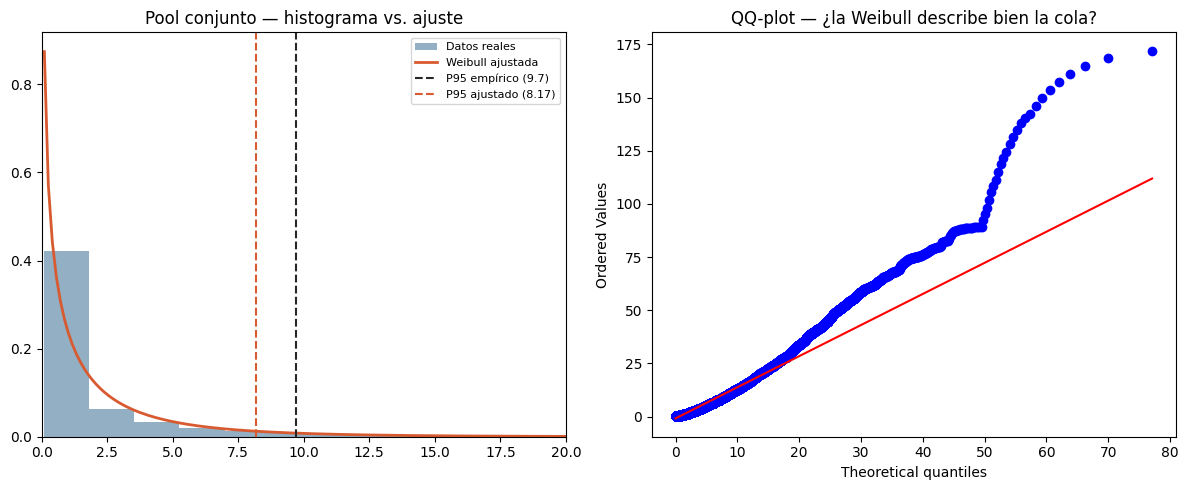

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histograma real vs. curva ajustada, sobre el pool
valores_pool = pool_total.values
axes[0].hist(valores_pool, bins=100, density=True, alpha=0.6, color='#4A7B9D', label='Datos reales')
x = np.linspace(0.1, np.percentile(valores_pool, 99.5), 200)
axes[0].plot(x, weibull_min.pdf(x, resultado_pool['forma'], loc=0, scale=resultado_pool['escala']),
             color='#D85A30', lw=2, label='Weibull ajustada')
axes[0].axvline(resultado_pool['p95_empirico'], color='#262626', ls='--', label=f"P95 empírico ({resultado_pool['p95_empirico']})")
axes[0].axvline(resultado_pool['p95_ajustado'], color='#D85A30', ls='--', label=f"P95 ajustado ({resultado_pool['p95_ajustado']})")
axes[0].set_xlim(0, 20)
axes[0].legend(fontsize=8)
axes[0].set_title('Pool conjunto — histograma vs. ajuste')

# QQ-plot: cuantiles empíricos vs. cuantiles teóricos de la Weibull ajustada
from scipy.stats import probplot
probplot(valores_pool, dist=weibull_min, sparams=(resultado_pool['forma'], 0, resultado_pool['escala']), plot=axes[1])
axes[1].set_title('QQ-plot — ¿la Weibull describe bien la cola?')

plt.tight_layout()
plt.show()

Weibull floc=0 (anterior): forma=0.682, escala=1.634, P95=8.17
Weibull loc libre (nuevo): forma=0.565, loc=0.100, escala=1.113, P95=7.86
P95 empírico (referencia): 9.7


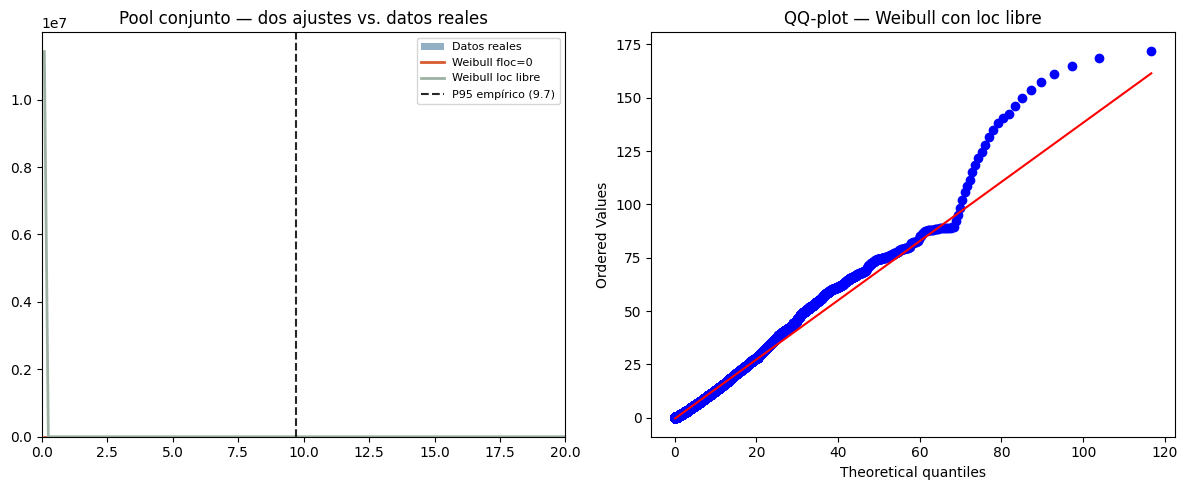

In [4]:
# Weibull con loc libre (3 parámetros), en vez de floc=0 fijo
forma_libre, loc_libre, escala_libre = weibull_min.fit(pool_total.values)
p95_ajustado_libre = weibull_min.ppf(0.95, forma_libre, loc=loc_libre, scale=escala_libre)

print(f"Weibull floc=0 (anterior): forma={resultado_pool['forma']}, escala={resultado_pool['escala']}, P95={resultado_pool['p95_ajustado']}")
print(f"Weibull loc libre (nuevo): forma={forma_libre:.3f}, loc={loc_libre:.3f}, escala={escala_libre:.3f}, P95={p95_ajustado_libre:.2f}")
print(f"P95 empírico (referencia): {resultado_pool['p95_empirico']}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

valores_pool = pool_total.values
axes[0].hist(valores_pool, bins=100, density=True, alpha=0.6, color='#4A7B9D', label='Datos reales')
x = np.linspace(0.1, np.percentile(valores_pool, 99.5), 200)
axes[0].plot(x, weibull_min.pdf(x, resultado_pool['forma'], loc=0, scale=resultado_pool['escala']),
             color='#D85A30', lw=2, label='Weibull floc=0')
axes[0].plot(x, weibull_min.pdf(x, forma_libre, loc=loc_libre, scale=escala_libre),
             color='#9EB2A4', lw=2, label='Weibull loc libre')
axes[0].axvline(resultado_pool['p95_empirico'], color='#262626', ls='--', label=f"P95 empírico ({resultado_pool['p95_empirico']})")
axes[0].set_xlim(0, 20)
axes[0].legend(fontsize=8)
axes[0].set_title('Pool conjunto — dos ajustes vs. datos reales')

probplot(valores_pool, dist=weibull_min, sparams=(forma_libre, loc_libre, escala_libre), plot=axes[1])
axes[1].set_title('QQ-plot — Weibull con loc libre')

plt.tight_layout()
plt.show()

**Hallazgo crítico, pendiente de resolver:** el ajuste Weibull (tanto
con `floc=0` como con `loc` libre) subestima sistemáticamente el P95
frente al valor empírico — 8.17 y 7.86 respectivamente, contra 9.7
empírico (15-19% de subestimación). El QQ-plot confirma que la Weibull
no captura bien la cola pesada de la distribución de horas húmedas,
independientemente de la parametrización. El `loc` libre (0.100)
coincide, de forma coherente, con el piso instrumental de hora húmeda
ya fijado (Ban et al., 2015) — no es un artefacto del ajuste.

**Pendiente:** decidir entre (a) usar el P95 empírico directo,
apartándose del ajuste paramétrico de Schär et al. (2016), o (b) probar
una familia de distribución con más flexibilidad de cola (Gamma,
log-normal, Weibull generalizada) antes de comprometerse con un umbral
final.